# 01 · Raw data EDA — CoAHD (FAOSTAT) and MDD-W (FAOSTAT SDG 2.2.4)

Purpose: look at the raw files before any joining. What is the coverage, which years, which sources, any oddities?

In [1]:
import json, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_rows", 200, "display.width", 160)
RAW = "../data/raw"
cahd = pd.read_csv(f"{RAW}/CAHD/Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).csv", encoding="utf-8")
sdg  = pd.read_csv(f"{RAW}/SDGB/SDG_BulkDownloads_E_All_Data_(Normalized).csv", encoding="utf-8", low_memory=False)
# SDG Value is read as text because some indicators are censored (e.g. "<2.5"); coerce, none of the MDD-W rows are censored
sdg["Value"] = pd.to_numeric(sdg["Value"], errors="coerce")
cahd.shape, sdg.shape

((10320, 14), (476072, 14))

## CoAHD — items, release, coverage

In [2]:
cahd["Item"].value_counts()

Item
Cost of a healthy diet (CoHD)                             3132
Prevalence of unaffordability (PUA)                       1935
Number of people unable to afford a healthy diet (NUA)    1935
Cost of a healthy diet (CoHD), simple average              369
Cost of a healthy diet (CoHD), weighted average            369
Cost of starchy staples                                    348
Cost of animal source foods                                348
Cost of legumes, nuts and seeds                            348
Cost of vegetables                                         348
Cost of fruits                                             348
Cost of oils and fats                                      348
Cost of starchy staples, simple average                     41
Cost of starchy staples, weighted average                   41
Cost of animal source foods, simple average                 41
Cost of animal source foods, weighted average               41
Cost of legumes, nuts and seeds, simple average   

In [3]:
cahd["Release"].value_counts()

Release
July 2026 (SOFI report)    10320
Name: count, dtype: int64

In [4]:
# PUA = prevalence of unaffordability (% of population). Country rows have Area Code < 5000; >= 5000 are aggregates.
pua = cahd[(cahd["Item Code"] == 7005) & (cahd["Area Code"] < 5000) & cahd["Value"].notna()]
print("countries:", pua["Area"].nunique())
pua.pivot_table(index="Year", values="Value", aggfunc=["count", "median", "min", "max"])

countries: 149


,count,median,min,max
,Value,Value,Value,Value
Year,,,,
2017,149,32.30,0.1,95.8
2018,149,29.30,0.1,93.7
2019,149,28.60,0.1,93.2
2020,149,31.00,0.8,93.7
2021,149,28.30,0.9,93.4
2022,149,27.90,0.8,93.8
2023,149,27.10,0.8,92.6
2024,148,27.10,0.7,95.0


In [5]:
# Cost of a healthy diet (PPP$/person/day) — the other CAHD headline number
cohd = cahd[(cahd["Item Code"] == 70040) & (cahd["Area Code"] < 5000) & cahd["Value"].notna()]
cohd.pivot_table(index="Year", values="Value", aggfunc=["count", "median", "min", "max"])

,count,median,min,max
,Value,Value,Value,Value
Year,,,,
2017,166,3.045,1.70,5.48
2018,166,3.120,1.75,5.65
2019,166,3.240,1.83,5.57
2020,166,3.390,1.86,5.80
2021,166,3.530,1.90,5.98
2022,166,3.950,2.23,6.62
2023,166,4.305,2.58,7.48
2024,165,4.450,2.66,7.79


In [6]:
# Which countries have PUA but are missing the most recent year? (149 vs 148)
have = pua.groupby("Area")["Year"].max()
have[have < pua["Year"].max()]

Area
Nicaragua    2023
Name: Year, dtype: int64

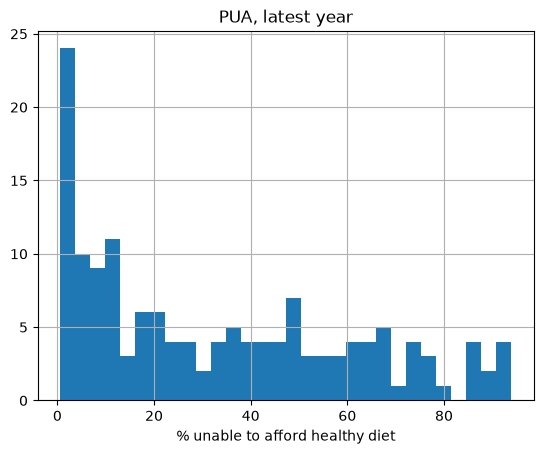

In [7]:
pua[pua["Year"] == pua["Year"].max()]["Value"].hist(bins=30); plt.title("PUA, latest year"); plt.xlabel("% unable to afford healthy diet");

## MDD-W — SDG 2.2.4 in the SDGB domain

Item `24049-F-Y15T49T` = national, no urban/rural breakdown. Flags: A = official, E = estimated (aggregates), O = missing.

In [8]:
mdd_all = sdg[sdg["Item Code"].astype(str).str.startswith("24049")]
mdd_all["Item"].value_counts()

Item
2.2.4 Prevalence of minimum dietary diversity among non-pregnant women aged 15-49 years (no breakdown by urbanisation)    1320
2.2.4 Prevalence of minimum dietary diversity among non-pregnant women aged 15-49 years (rural)                            460
2.2.4 Prevalence of minimum dietary diversity among non-pregnant women aged 15-49 years (urban)                            460
Name: count, dtype: int64

In [9]:
mdd = mdd_all[(mdd_all["Item Code"] == "24049-F-Y15T49T") & (mdd_all["Area Code"] < 5000) & mdd_all["Value"].notna()].copy()
print("countries with a value:", mdd["Area"].nunique(), "| country-years:", len(mdd))
print(mdd["Flag"].value_counts().to_dict())
mdd["Year"].value_counts().sort_index()

countries with a value: 80 | country-years: 109
{'A': 106, 'E': 3}


Year
2016     2
2017     5
2018     3
2019     3
2020     1
2021    28
2022    18
2023    33
2024    15
2025     1
Name: count, dtype: int64

In [10]:
# Data source is embedded in the Note column. Pull the text after the first '|'.
mdd["source"] = mdd["Note"].str.split("|").str[1].str.split(":").str[0].str.strip()
mdd["source"].value_counts()

source
Global Diet Quality Project                                      67
DHS Program                                                      19
DHS Program https                                                 2
SMART Survey Burkina Faso 2023                                    1
CFSVA Burundi                                                     1
Gambia Micronutrient Survey 2018                                  1
Ghana Micronutrient Survey 2017                                   1
The Jordan National Micronutrient Survey                          1
NIMAS Kyrgyz Republic                                             1
LIMA Survey Report                                                1
Mauritius Nutrition Survey                                        1
Nutrition Status of the Population of Mongolia                    1
DHS program                                                       1
ONNS Report 2017                                                  1
Rwanda Comprehensive Food Security and Vu

In [11]:
# Countries with more than one survey — how consistent are repeat measurements?
multi = mdd.groupby("Area").filter(lambda g: len(g) > 1)
multi[["Area", "Year", "Value", "source"]].sort_values(["Area", "Year"])

,Area,Year,Value,source
55006,Burkina Faso,2021,25.10,DHS Program
55008,Burkina Faso,2023,17.50,SMART Survey Burkina Faso 2023
60884,Cambodia,2021,66.37,Global Diet Quality Project
60885,Cambodia,2022,57.30,DHS Program
89150,Côte d'Ivoire,2021,29.40,DHS Program
89152,Côte d'Ivoire,2023,40.48,Global Diet Quality Project
100887,Democratic Republic of the Congo,2023,48.97,Global Diet Quality Project
100888,Democratic Republic of the Congo,2024,17.20,DHS Program
143655,Ghana,2017,47.20,Ghana Micronutrient Survey 2017
143659,Ghana,2021,44.14,Global Diet Quality Project


**Watch out:** several countries have a Global Diet Quality Project (Gallup World Poll) estimate and a DHS/national survey estimate a year or two apart that differ by 20–30 points (DRC, Mozambique, Malawi, Tanzania, Mali). Survey mode matters. We'll carry `source` into the panel and treat it as a robustness dimension.

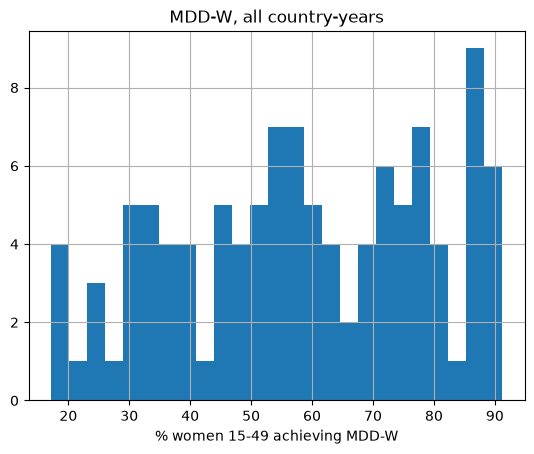

In [12]:
mdd["Value"].hist(bins=25); plt.title("MDD-W, all country-years"); plt.xlabel("% women 15-49 achieving MDD-W");

In [13]:
# Urban vs rural where available (item codes ...U / ...R)
ur = mdd_all[(mdd_all["Area Code"] < 5000) & mdd_all["Value"].notna() & mdd_all["Item Code"].isin(["24049-F-Y15T49U", "24049-F-Y15T49R"])]
ur.pivot_table(index=["Area", "Year"], columns="Item Code", values="Value").dropna().head(30)

,Item Code,24049-F-Y15T49R,24049-F-Y15T49U
Area,Year,,
Angola,2024,19.4,38.2
Burkina Faso,2021,22.3,31.1
Burundi,2023,15.0,40.6
Cambodia,2022,49.8,67.6
Côte d'Ivoire,2021,22.7,33.8
Democratic Republic of the Congo,2024,11.7,24.9
Ghana,2022,46.7,52.4
Jordan,2023,77.1,76.3
Kenya,2022,43.0,54.6


## World Bank metadata and GDP per capita PPP

In [14]:
wb = pd.DataFrame(json.load(open(f"{RAW}/wb_countries.json"))[1])
wb = wb[wb["region"].apply(lambda r: r["id"]) != "NA"]  # drop aggregates
wb["income"] = wb["incomeLevel"].apply(lambda r: r["value"]); wb["region_name"] = wb["region"].apply(lambda r: r["value"].strip())
print(len(wb)); wb["income"].value_counts()

217


income
High income            86
Upper middle income    59
Lower middle income    47
Low income             25
Name: count, dtype: int64

In [15]:
gdp = pd.DataFrame(json.load(open(f"{RAW}/wb_gdp_pcap_ppp.json"))[1])
gdp = gdp[gdp["value"].notna()][["countryiso3code", "date", "value"]]
gdp["date"] = gdp["date"].astype(int)
gdp.groupby("date")["value"].agg(["count", "median"])

,count,median
date,,
2015,246,14541.253089
2016,246,15106.920158
2017,246,15480.668862
2018,246,16154.994771
2019,246,16559.734474
2020,246,15506.249531
2021,246,16230.384732
2022,246,16932.969639
2023,244,17366.521197


## Overlap check (by name, rough) — how many MDD-W countries also have PUA?
The real join in `02_build_panel.py` uses ISO3 codes; this is just a sanity preview.

In [16]:
both = set(mdd["Area"]) & set(pua["Area"]); only_mdd = set(mdd["Area"]) - set(pua["Area"])
print("in both:", len(both)); print("MDD-W only:", sorted(only_mdd))

in both: 67
MDD-W only: ['Afghanistan', 'Cambodia', 'Georgia', 'Libya', 'Oman', 'Somalia', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Ukraine', 'Vanuatu', 'Venezuela (Bolivarian Republic of)', 'Zimbabwe']
